# Simulation 3 — Ring resonator Q-factor and FSR

A **ring resonator** filters wavelengths: on resonance the round-trip phase satisfies $2\\pi r n_{\\mathrm{eff}} = m\\lambda$. The transmission spectrum shows periodic notches with free spectral range $\\mathrm{FSR} \\approx \\lambda^2 / (n_g L)$ and linewidth set by coupling and loss (Q-factor).

We inject a broadband Gaussian pulse, record bus flux, and fit a Lorentzian to the deepest resonance.

In [ ]:
import matplotlib.pyplot as plt
import tidy3d.web as web

from fdtd_pic.analytics.ring import analytical_fsr_hz, fit_resonance, measured_fsr
from fdtd_pic.config import RING_RADIUS
from fdtd_pic.plotting import apply_style, save_figure
from fdtd_pic.ring import build_ring_simulation, extract_transmission_spectrum

apply_style()

In [ ]:
sim = build_ring_simulation()
sim.plot(z=0)
plt.title('Ring resonator geometry')
plt.show()


# ring gap at 3 0clock seems to be the way the polygons are defined, looking into a fix.
# fixed! - see commit 105cfae


# ahhhh i missed that the ring was clipped so the ring actually isnt connectted to itself, need to fix this and re-run

# think i fixed, waiting to commit.

In [ ]:
# simulating and web run

sim_data = web.run(sim, task_name='ring', verbose=True)
freqs, transmission = extract_transmission_spectrum(sim_data)

fig, ax = plt.subplots()
ax.plot(freqs / 1e12, transmission)
ax.set_xlabel('Frequency (THz)')
ax.set_ylabel('Through transmission')
ax.set_title('Ring transmission spectrum')
save_figure(fig, '../assets/ring_transmission_spectrum.png')
plt.show()

**Explanation (what i think) of figure above**

dip deths vary considerably, shallow up untill 187~THz, deeping untill 210THZ. - im thinking this is maybe due to the ring hosting different resonances which would differ in coupling strength or quality factor across the band?. --- dip depth is set by how close we are to critical coupling.

Broader envelope perhaps due to incomplete field decay, but a much larger simulation time would likely be required as we have a long lasting resonance? --- the fact that transmission is apparently >1 is a clear sign the simulation has not fully converged.

the 190 - 210 THz range is likely the high Q family.


Note on ring radius:

our 10 micron ring has little bend loss compared to ultra compact submicron PIC's. High Q -> slower enrgy decay, simulating untill field decay too expensive and not neccessary for this project.

FSR = c / (Ng * 2*pi*R) --- for silicon waveguides at our 1550nm wavelength, with a Ng approx 4.2, FSR would be likely 1.1 THz ---- **given we have 5 peaks in the 190 - 195 THz RANGE, THIS IS CONSISTENT WITH my SIMULATION**



In [ ]:
sim_data = web.load(
    "fdve-d5651f47-9249-4eb9-bd7b-6622d80b4b10",
    path=".tidy3d_cache/ring.hdf5",
    verbose=True,
)

In [ ]:
freqs, transmission = extract_transmission_spectrum(sim_data)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from fdtd_pic.analytics.ring import analytical_fsr_hz, fit_resonance, measured_fsr
from fdtd_pic.config import RING_RADIUS
from fdtd_pic.plotting import save_figure

# --- choose your analysis window (pick one style) ---

# Style A: frequency in THz (easy to read)
f_min_thz = 187.0
f_max_thz = 210.0

mask = (freqs / 1e12 >= f_min_thz) & (freqs / 1e12 <= f_max_thz)

# Subset for analysis
freqs_win = freqs[mask]
trans_win = transmission[mask]

print(f"Using {freqs_win.size} points in selected band")
print(f"Band: {freqs_win.min()/1e12:.3f} – {freqs_win.max()/1e12:.3f} THz")

# Fit / FSR only inside window
fit = fit_resonance(freqs_win, trans_win)
fsr_sim = measured_fsr(freqs_win, trans_win)
fsr_analytical_hz = analytical_fsr_hz(RING_RADIUS)

print(f"Resonance f0 = {fit.f0/1e12:.3f} THz")
print(f"Q = {fit.q_factor:.0f}")
print(f"FSR (sim) ~ {fsr_sim/1e12:.4f} THz" if fsr_sim == fsr_sim else "FSR (sim): n/a")
print(f"FSR (analytical) ~ {fsr_analytical_hz/1e12:.4f} THz")

# Plot only window
fig, ax = plt.subplots()
ax.plot(freqs_win / 1e12, trans_win, label="FDTD (selected band)")
ax.axvline(fit.f0 / 1e12, color="r", ls="--", label=f"fit f0, Q={fit.q_factor:.0f}")
ax.set_xlim(f_min_thz, f_max_thz)   # optional if you used Style A
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Transmission")
ax.legend()
save_figure(fig, "../assets/ring_lorentzian_fit.png")
plt.show()

## Key takeaway -- Ignore Q, FSR more reasonable value currently

Fit is being pulled by ripples from a wide band --- not tracking one nice resonance peak....

linewidth: Q = 9 (???) and f_0 ~ 198THz, linewidth f_0/Q ~ 22THz -. NERLY 20X WIDER THAN fsr ~ 1.16 THz -- physically inconsistent for a real cavity resonance.

- Data points too coarse to window onto a small frequency region, would be pointless


## Second attempt, fixing issues seen above with clarity of resonant peaks - 7 credits, 3.8x previous



Finer frequency, properly fitted lorentzian (hopefully) to find Q

In [12]:
# --- imports & repo root ---
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web

from fdtd_pic.analytics.ring import fit_resonance, lorentzian
from fdtd_pic.config import (
    DEFAULT_WIDTH,
    FREQ0,
    FWIDTH,
    HEIGHT,
    PML_SPACING,
    RING_GAP,
    RING_RADIUS,
    WAVELENGTH,
)
from fdtd_pic.plotting import save_figure
from fdtd_pic.ring import extract_transmission_spectrum, make_ring_structures
from fdtd_pic.materials import sio2_medium

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    os.chdir(ROOT.parent)
print("cwd:", Path.cwd())



# --- knobs (edit these) ---
F0_HZ = 194e12          # from pass-1 broad fit (Hz)
DF_THZ = 1.0               # half-width of fine band (THz) → ±0.25 THz window
DF_STEP_THZ = 0.01          # frequency spacing (THz)- need high res 
RING_GAP_FINE = RING_GAP    # try 0.15 or 0.1 if dip is shallow
RUN_TIME_S = 1e-10          # tune so num_time_steps < 9e6
MIN_STEPS = 8
SHUTOFF = 1e-3              # on Simulation object (not web.run)
TASK_NAME = "ring_finer"
CACHE_PATH = Path(".tidy3d_cache") / f"{TASK_NAME}.hdf5"
MAX_STEPS = 9_000_000
MAX_EST_CREDITS = 10.0
FORCE_RERUN = True          # set False after one verified good run

# --- build fine-band simulation ---
def build_ring_simulation_fine(
    f_center_hz: float,
    *,
    df_thz: float = 0.25,
    df_step_thz: float = 0.03,
    radius: float = RING_RADIUS,
    gap: float = RING_GAP,
    width: float = DEFAULT_WIDTH,
    bus_length: float = 30.0,
    run_time: float = RUN_TIME_S,
    min_steps_per_wvl: int = MIN_STEPS,
    shutoff: float = SHUTOFF,
) -> td.Simulation:
    """Ring FDTD with dense flux/field monitors around one resonance."""
    f_min = f_center_hz - df_thz * 1e12
    f_max = f_center_hz + df_thz * 1e12
    freqs = np.arange(f_min, f_max + 1e6, df_step_thz * 1e12)  # +1e6 Hz avoids float edge miss
    if freqs.size < 5:
        raise ValueError(
            f"Only {freqs.size} frequency points — increase df_thz or decrease df_step_thz"
        )

    ring_center_y = radius + gap + width
    r_outer = radius + width / 2
    structures = make_ring_structures(radius=radius, gap=gap, width=width, bus_length=bus_length)

    y_min = min(-width / 2, ring_center_y - r_outer)
    y_max = max(width / 2, ring_center_y + r_outer)
    x_min = min(-bus_length / 2, -r_outer)
    x_max = max(bus_length / 2, r_outer)
    buffer = WAVELENGTH
    sim_x = (x_max - x_min) + 2 * PML_SPACING + buffer
    sim_y = (y_max - y_min) + 2 * PML_SPACING + buffer
    sim_z = HEIGHT + 2 * PML_SPACING
    sim_center = ((x_max + x_min) / 2, (y_max + y_min) / 2, 0.0)

    x_src = -bus_length / 2 + PML_SPACING + 0.5
    x_mon = bus_length / 2 - PML_SPACING - 0.5

    source_time = td.GaussianPulse(freq0=FREQ0, fwidth=FWIDTH)
    freq_list = [float(f) for f in freqs]

    source = td.ModeSource(
        center=(x_src, 0.0, 0.0),
        size=(0, width, sim_z),
        source_time=source_time,
        direction="+",
        mode_spec=td.ModeSpec(num_modes=1),
        name="source",
    )
    flux_in = td.FluxMonitor(
        center=(x_src + 0.5, 0.0, 0.0),
        size=(0, width, sim_z),
        freqs=freq_list,
        name="flux_in",
    )
    flux_out = td.FluxMonitor(
        center=(x_mon, 0.0, 0.0),
        size=(0, width, sim_z),
        freqs=freq_list,
        name="flux_out",
    )
    field_monitor = td.FieldMonitor(
        center=(0, (y_max + y_min) / 2, 0),
        size=(td.inf, td.inf, 0),
        freqs=freq_list,
        name="field_xy",
    )

    return td.Simulation(
        size=(sim_x, sim_y, sim_z),
        center=sim_center,
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=min_steps_per_wvl,
            wavelength=WAVELENGTH,
        ),
        structures=structures,
        sources=[source],
        monitors=[flux_in, flux_out, field_monitor],
        run_time=run_time,
        shutoff=shutoff,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        medium=sio2_medium(),
    )

def verify_loaded_data(sim_data: td.SimulationData, df_thz: float) -> tuple[np.ndarray, np.ndarray]:
    """Confirm HDF5 really contains fine-band data."""
    freqs, transmission = extract_transmission_spectrum(sim_data)
    band_thz = freqs.max() / 1e12 - freqs.min() / 1e12

    print("--- post-load data check ---")
    print(f"loaded flux points: {freqs.size}")
    print(f"loaded THz range: {freqs.min()/1e12:.4f} – {freqs.max()/1e12:.4f}")
    print(f"loaded band width: {band_thz:.4f} THz")

    if freqs.size > 50 or band_thz > 2 * df_thz + 0.05:
        raise RuntimeError(
            "Loaded data looks like OLD BROAD simulation. "
            "Delete cache, set FORCE_RERUN=True, use new TASK_NAME."
        )
    return freqs, transmission

def nearest_monitor_freq(sim_data: td.SimulationData, f_target_hz: float) -> float:
    freqs_avail = np.asarray(sim_data["field_xy"].Ey.f.values, dtype=float)
    idx = int(np.argmin(np.abs(freqs_avail - f_target_hz)))
    f_pick = float(freqs_avail[idx])
    print(f"nearest field freq to {f_target_hz/1e12:.4f} THz → {f_pick/1e12:.4f} THz")
    return f_pick

sim_fine = build_ring_simulation_fine(
    F0_HZ,
    df_thz=DF_THZ,
    df_step_thz=DF_STEP_THZ,
    gap=RING_GAP_FINE,
    run_time=RUN_TIME_S,
    min_steps_per_wvl=MIN_STEPS,
    shutoff=SHUTOFF,
)


job = web.Job(simulation=sim_fine, task_name=TASK_NAME, verbose=True)
print("Est cost:", web.estimate_cost(job.task_id))

sim_data_fine = web.run(
    sim_fine,
    task_name=TASK_NAME,
    path=str(CACHE_PATH),
    verbose=True,
)

cwd: /workspaces/fdtd-pic-simulations


15:45:16 UTC Created task 'ring_finer' with resource_id                         
             'fdve-789b9111-0561-4f41-a835-5cbc9c748a9a' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=8743126;https://tidy3d.simulation.cloud/workbench?taskId=fdve-789b9111-0561-4f41-a835-5cbc9c748a9a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=8743127;https://tidy3d.simulation.cloud/workbench?taskId=fdve-789b9111-0561-4f41-a835-5cbc9c748a9a\taskId]8;;\]8;id=8743126;https://tidy3d.simulation.cloud/workbench?taskId=fdve-789b9111-0561-4f41-a835-5cbc9c748a9a\=]8;;\]8;id=8743128;https://tidy3d.simulation.cloud/workbench?taskId=fdve-789b9111-0561-4f41-a835-5cbc9c748a9a\fdve]8;;\]8;id=8743126;https://tidy3d.simulation.cloud/workbench?taskId=fdve-789b9111-0561-4f41-a835-5cbc9c748a9a\-789b9111-056]8;;\
             ]8;id=8743126;https://tidy3d.simulation.cloud/workbench?taskId=fdve-789b9111-0561-4f41-a835-5cbc9c748a9a\1-4f41-a835-5cbc9c748a9a']8;;\.

             Task folder: ]8;id=8743131;https://tidy3d.simulation.cloud/folders/folder-b1d0f035-084f-44be-bf27-206997efd5d6\'default']8;;\.

Output()

...

15:45:31 UTC status = preprocess

15:45:36 UTC starting up solver

             running solver

Output()

: 

In [1]:
# --- imports & repo root ---
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web

from fdtd_pic.analytics.ring import fit_resonance, lorentzian
from fdtd_pic.config import (
    DEFAULT_WIDTH,
    FREQ0,
    FWIDTH,
    HEIGHT,
    PML_SPACING,
    RING_GAP,
    RING_RADIUS,
    WAVELENGTH,
)
from fdtd_pic.plotting import save_figure
from fdtd_pic.ring import extract_transmission_spectrum, make_ring_structures
from fdtd_pic.materials import sio2_medium

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    os.chdir(ROOT.parent)
print("cwd:", Path.cwd())



# --- knobs (edit these) ---
F0_HZ = 194e12          # from pass-1 broad fit (Hz)
DF_THZ = 1.0               # half-width of fine band (THz) → ±0.25 THz window
DF_STEP_THZ = 0.01          # frequency spacing (THz)- need high res 
RING_GAP_FINE = RING_GAP    # try 0.15 or 0.1 if dip is shallow
RUN_TIME_S = 1e-10          # tune so num_time_steps < 9e6
MIN_STEPS = 8
SHUTOFF = 1e-3              # on Simulation object (not web.run)
TASK_NAME = "ring_finer"
CACHE_PATH = Path(".tidy3d_cache") / f"{TASK_NAME}.hdf5"
MAX_STEPS = 9_000_000
MAX_EST_CREDITS = 10.0
FORCE_RERUN = True          # set False after one verified good run

# --- build fine-band simulation ---
def build_ring_simulation_fine(
    f_center_hz: float,
    *,
    df_thz: float = 0.25,
    df_step_thz: float = 0.03,
    radius: float = RING_RADIUS,
    gap: float = RING_GAP,
    width: float = DEFAULT_WIDTH,
    bus_length: float = 30.0,
    run_time: float = RUN_TIME_S,
    min_steps_per_wvl: int = MIN_STEPS,
    shutoff: float = SHUTOFF,
) -> td.Simulation:
    """Ring FDTD with dense flux/field monitors around one resonance."""
    f_min = f_center_hz - df_thz * 1e12
    f_max = f_center_hz + df_thz * 1e12
    freqs = np.arange(f_min, f_max + 1e6, df_step_thz * 1e12)  # +1e6 Hz avoids float edge miss
    if freqs.size < 5:
        raise ValueError(
            f"Only {freqs.size} frequency points — increase df_thz or decrease df_step_thz"
        )

    ring_center_y = radius + gap + width
    r_outer = radius + width / 2
    structures = make_ring_structures(radius=radius, gap=gap, width=width, bus_length=bus_length)

    y_min = min(-width / 2, ring_center_y - r_outer)
    y_max = max(width / 2, ring_center_y + r_outer)
    x_min = min(-bus_length / 2, -r_outer)
    x_max = max(bus_length / 2, r_outer)
    buffer = WAVELENGTH
    sim_x = (x_max - x_min) + 2 * PML_SPACING + buffer
    sim_y = (y_max - y_min) + 2 * PML_SPACING + buffer
    sim_z = HEIGHT + 2 * PML_SPACING
    sim_center = ((x_max + x_min) / 2, (y_max + y_min) / 2, 0.0)

    x_src = -bus_length / 2 + PML_SPACING + 0.5
    x_mon = bus_length / 2 - PML_SPACING - 0.5

    source_time = td.GaussianPulse(freq0=FREQ0, fwidth=FWIDTH)
    freq_list = [float(f) for f in freqs]

    source = td.ModeSource(
        center=(x_src, 0.0, 0.0),
        size=(0, width, sim_z),
        source_time=source_time,
        direction="+",
        mode_spec=td.ModeSpec(num_modes=1),
        name="source",
    )
    flux_in = td.FluxMonitor(
        center=(x_src + 0.5, 0.0, 0.0),
        size=(0, width, sim_z),
        freqs=freq_list,
        name="flux_in",
    )
    flux_out = td.FluxMonitor(
        center=(x_mon, 0.0, 0.0),
        size=(0, width, sim_z),
        freqs=freq_list,
        name="flux_out",
    )
    field_monitor = td.FieldMonitor(
        center=(0, (y_max + y_min) / 2, 0),
        size=(td.inf, td.inf, 0),
        freqs=freq_list,
        name="field_xy",
    )

    return td.Simulation(
        size=(sim_x, sim_y, sim_z),
        center=sim_center,
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=min_steps_per_wvl,
            wavelength=WAVELENGTH,
        ),
        structures=structures,
        sources=[source],
        monitors=[flux_in, flux_out, field_monitor],
        run_time=run_time,
        shutoff=shutoff,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        medium=sio2_medium(),
    )


def nearest_monitor_freq(sim_data: td.SimulationData, f_target_hz: float) -> float:
    freqs_avail = np.asarray(sim_data["field_xy"].Ey.f.values, dtype=float)
    idx = int(np.argmin(np.abs(freqs_avail - f_target_hz)))
    f_pick = float(freqs_avail[idx])
    print(f"nearest field freq to {f_target_hz/1e12:.4f} THz → {f_pick/1e12:.4f} THz")
    return f_pick

cwd: /workspaces/fdtd-pic-simulations


In [2]:
import os
from pathlib import Path
import tidy3d as td
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
CACHE = ".tidy3d_cache/ring_finer.hdf5"
sim_data_fine = td.SimulationData.from_file(
    CACHE,
    monitor_names=["flux_in", "flux_out"],  # skip heavy field_xy
)
from fdtd_pic.ring import extract_transmission_spectrum
freqs, transmission = extract_transmission_spectrum(sim_data_fine)
print(len(freqs), "points")
print(freqs.min()/1e12, "–", freqs.max()/1e12, "THz")

201 points
193.0 – 195.0 THz


In [3]:
fit = fit_resonance(freqs, transmission)
T_min = float(transmission.min())
T_max = float(transmission.max())
extinction_db = -10.0 * np.log10(max(T_min, 1e-12) / max(T_max, 1e-12))
wl_res_um = 299_792_458.0 / fit.f0 * 1e6

print(f"Resonance f0 = {fit.f0 / 1e12:.4f} THz  (λ ≈ {wl_res_um:.4f} µm)")
print(f"Q = {fit.q_factor:.0f}")
print(f"Dip: T_min={T_min:.4f}, T_max={T_max:.4f}, extinction≈{extinction_db:.2f} dB")

Resonance f0 = 194.8779 THz  (λ ≈ 1.5384 µm)
Q = 10684
Dip: T_min=0.3375, T_max=1.0812, extinction≈5.06 dB


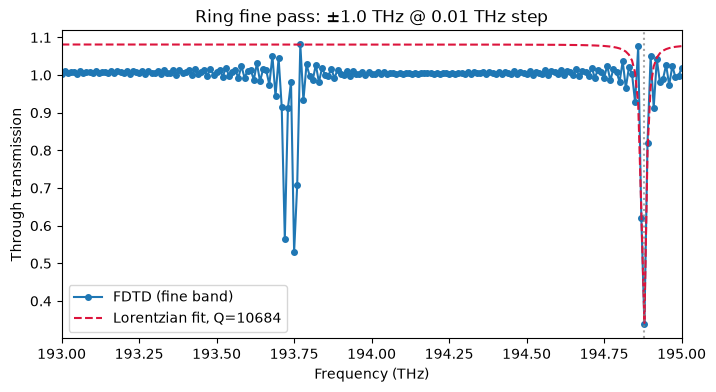

In [4]:
T_fit = T_max - lorentzian(freqs, fit.f0, fit.gamma, fit.amplitude)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs / 1e12, transmission, "o-", ms=4, label="FDTD (fine band)")
ax.plot(freqs / 1e12, T_fit, "--", color="crimson", label=f"Lorentzian fit, Q={fit.q_factor:.0f}")
ax.axvline(fit.f0 / 1e12, color="gray", ls=":", alpha=0.7)
ax.set_xlim(freqs.min() / 1e12, freqs.max() / 1e12)
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Through transmission")
ax.set_title(f"Ring fine pass: ±{DF_THZ} THz @ {DF_STEP_THZ} THz step")
ax.legend()
save_figure(fig, "assets/ring_fine_transmission.png")
plt.show()